In [1]:
import matplotlib.pyplot as plt
from collections import Counter
from data.load_data import extract_mtriples, extract_mtriples_by_category

In [2]:
xml_path = "data/long-inputs_GREC_3_10.xml"
result = extract_mtriples(xml_path)
sorted_data = extract_mtriples_by_category(xml_path)
sorted_data.keys()

dict_keys(['Cities', 'People'])

In [3]:
# result is the output of extract_mtriples()
length = [len(entry) for entry in result]

# Convert to a dict: {entry_index: triple_count}
entry_lengths = {f"Entry_{i}": count for i, count in enumerate(length)}

# print(f"Entry triple counts:\n {entry_lengths}")

# Get the values, sort them
lengths = sorted(entry_lengths.values())

# Find keys (entry indices) for min and max triple counts
max_key = max(entry_lengths, key=entry_lengths.get)
min_key = min(entry_lengths, key=entry_lengths.get)

# Print summary stats
print("Summary:")
print(f"Total entries: {len(lengths)}")
print(f"Minimum triples: {lengths[0]}")
print(f"Maximum triples: {lengths[-1]}")
print(f"Average triples: {sum(lengths) / len(lengths):.2f}")
print(f"Entry with maximum triples: Entry {max_key} → {entry_lengths[max_key]} triples")
print(f"Entry with minimum triples: Entry {min_key} → {entry_lengths[min_key]} triples")


Summary:
Total entries: 533
Minimum triples: 10
Maximum triples: 86
Average triples: 26.30
Entry with maximum triples: Entry Entry_105 → 86 triples
Entry with minimum triples: Entry Entry_199 → 10 triples


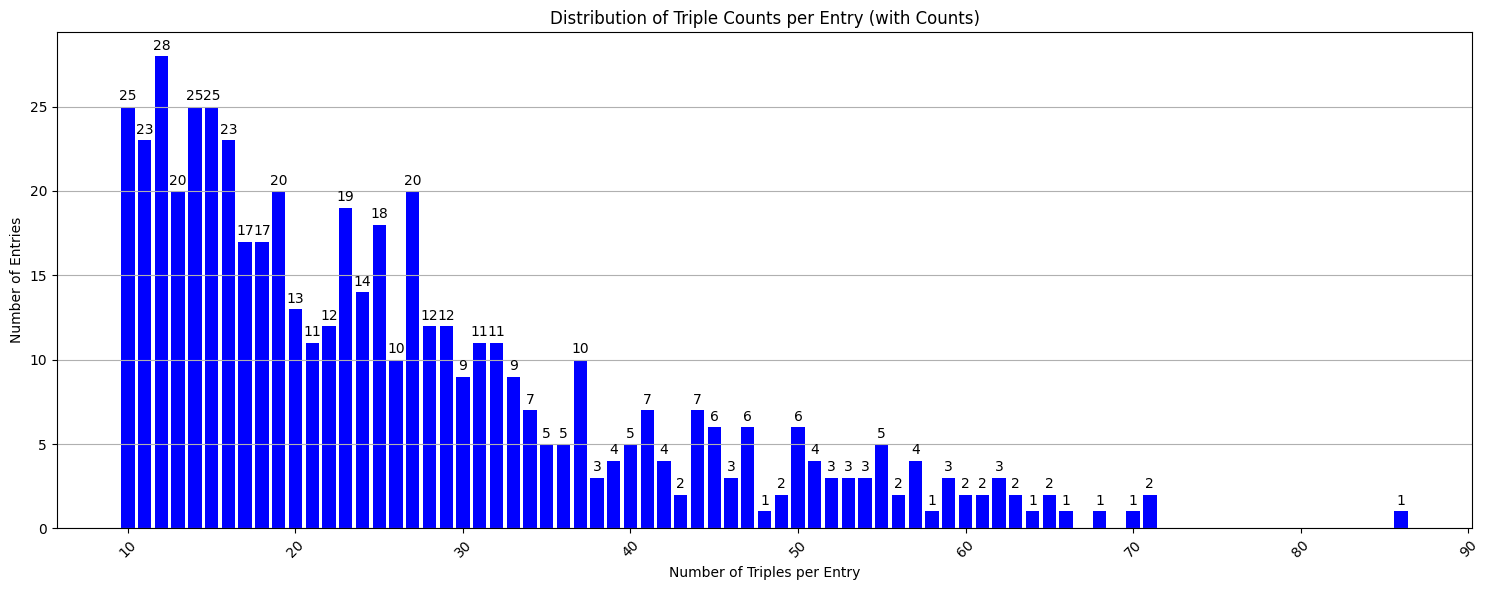

In [4]:
# Calculate the distribution
length_counts = Counter(lengths)
sorted_lengths = sorted(length_counts.items())
x_vals, y_vals = zip(*sorted_lengths)

# Enhanced Plotting Code75
plt.figure(figsize=(15, 6))
bars = plt.bar(x_vals, y_vals, color='blue')

# Annotate each bar with the count value
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.2, str(height),
             ha='center', va='bottom', fontsize=10)

# Axis labeling and aesthetics
plt.xlabel('Number of Triples per Entry')
plt.ylabel('Number of Entries')
plt.title('Distribution of Triple Counts per Entry (with Counts)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()

# Save plot locally (uncomment the line below to save)
plt.savefig("triple_distribution.png", dpi=300)
plt.show()

In [5]:
g60 = [n for n, i in enumerate(length)  if i > 60]
g60

[2, 10, 26, 35, 37, 50, 82, 85, 92, 95, 99, 105, 137, 158, 159, 213]

In [6]:
n = 85
len(result[n])

66

In [7]:
from utilities.llm_model import UnifiedModel, model_name
from utilities.prompt import MODEL_PROMPT, MODEL_PROMPT2, INPUT_PROMPT

provider = "groq"
conf = model_name.get(provider.lower())
llm = UnifiedModel(provider=provider, **conf).model_(MODEL_PROMPT)
output = llm.invoke(INPUT_PROMPT.format(triples=result[n])).content.strip()
print(f"\nGenerated Text:\n{output}")



Generated Text:
Islamabad, the federal capital of Pakistan, is a city rich in history and modern development. Established on August 14, 1967, it was designed by the renowned Greek architect Constantinos Apostolou Doxiadis, who considered it one of his most significant projects. The city is situated in the Margalla Hills National Park, offering a unique blend of natural beauty and urban planning. Islamabad has a total area of 220 square kilometers, with the metropolitan area spanning 1,165.5 square kilometers and an urban area covering 220.15 square kilometers. The city is home to a diverse population, with a total population of 1,009,832 and a metropolitan population of 2,003,368. The population density is approximately 2,089 people per square kilometer, reflecting its status as a bustling yet well-planned city.

Islamabad serves as the political and administrative heart of Pakistan, housing key institutions such as the Cabinet Secretariat and the Capital Development Authority. The ci

In [8]:
result[n]

[['Islamabad', 'areaMetro', '1165500000.0'],
 ['Islamabad', 'areaUrban', '220150000.0'],
 ['Islamabad', 'populationMetro', '2003368'],
 ['Islamabad', 'areaMetro', '1165.5'],
 ['Islamabad', 'areaTotal', '220.0'],
 ['Islamabad', 'areaUrban', '220.15'],
 ['Islamabad', 'populationDensity', '2089.0'],
 ['Islamabad', 'areaCode', '051'],
 ['Islamabad', 'areaTotal', '220000000.0'],
 ['Islamabad', 'demonym', 'Islamabadi'],
 ['Islamabad', 'foundingDate', '1967-08-14'],
 ['Islamabad', 'populationDensity', '2089.0'],
 ['Islamabad', 'populationTotal', '1009832'],
 ['Islamabad', 'postalCode', '44000'],
 ['Islamabad', 'utcOffset', '+05:00'],
 ['Islamabad', 'country', 'Pakistan'],
 ['Islamabad', 'governmentType', 'Islamabad_Metropolitan_Corporation'],
 ['Islamabad', 'timeZone', 'Pakistan_Standard_Time'],
 ['Islamabad', 'type', 'Federal_capital'],
 ['Cabinet_Secretariat_(Pakistan)', 'location', 'Islamabad'],
 ['Capital_Development_Authority_(Islamabad)', 'location', 'Islamabad'],
 ['Capital_Talk', 'loc